In [96]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv')

In [97]:
df. head ()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [98]:
df. tail ()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,...,No,No,No,No,No,No,No,No,No,NO


In [99]:
df. describe ()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


Cleaning Data

In [100]:
df['race'] = df['race'].replace('?', 'Unknown')
df['gender'] = df['gender'].replace('Unknown/Invalid', 'Unspecified')
df['age'] = df['age'].str.strip('[').str.strip(')')
df['weight'] = df['weight'].replace('?', 'NA')
df['readmitted'] = df['readmitted'].replace('<30', 'within 30days')
df['readmitted'] = df['readmitted'].replace('>30', 'After Month')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,0-10,NA,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,10-20,NA,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,After Month
2,64410,86047875,AfricanAmerican,Female,20-30,NA,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,30-40,NA,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,40-50,NA,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


Group

In [101]:
df.groupby(['gender', 'insulin'])['time_in_hospital'].mean()

gender       insulin
Female       Down       4.934173
             No         4.195709
             Steady     4.452132
             Up         5.253910
Male         Down       4.908089
             No         3.943655
             Steady     4.261639
             Up         5.225971
Unspecified  No         3.333333
Name: time_in_hospital, dtype: float64

Descriptive Statistics

In [102]:
print(df.groupby(['gender'])['time_in_hospital'].describe())

               count      mean       std  min  25%  50%  75%   max
gender                                                            
Female       54708.0  4.478797  2.980388  1.0  2.0  4.0  6.0  14.0
Male         47055.0  4.299777  2.987703  1.0  2.0  3.0  6.0  14.0
Unspecified      3.0  3.333333  4.041452  1.0  1.0  1.0  4.5   8.0


In [103]:
print(df.groupby(['gender'])['time_in_hospital'].mean())

gender
Female         4.478797
Male           4.299777
Unspecified    3.333333
Name: time_in_hospital, dtype: float64


In [104]:
print(df.groupby(['insulin'])['time_in_hospital'].mean())

insulin
Down      4.922164
No        4.079248
Steady    4.364193
Up        5.240809
Name: time_in_hospital, dtype: float64


In [105]:
import seaborn as sns


In [106]:
import matplotlib.pyplot as plt

Visualization

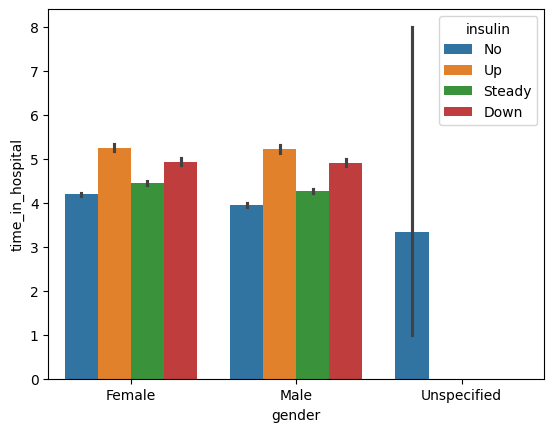

In [107]:
sns.barplot(x='gender',y='time_in_hospital',hue='insulin', data=df)

plt.show()

The data indentifies that female patients tend to stay in the hospital slightly longer than the male patients. However, Insulin remain "UP" while patients are in hospital.  